# Stable Diffusion, from the ground up  <sup>🧨 `diffusers`</sup>

**Lab plan**

1. **What is Stable Diffusion?** — what problem it solves, and its three parts
2. **The architecture & the training objective** — straight from the paper
3. **Train it** on anime faces with real Danbooru **tags** as text
4. **The problem:** plain conditional diffusion follows prompts *weakly*
5. **Fix #1 — classifier guidance** (and why it's a pain)
6. **Fix #2 — classifier-free guidance** (what everyone actually uses)
7. **Mix & match** pretrained VAEs / text encoders / UNets into your own pipelines

Only the **UNet** is trained here. The **VAE** and **CLIP** are frozen and pretrained.

## 1. What is Stable Diffusion?

### The problem it came to solve

A diffusion model learns to turn noise into an image by denoising it step by step. Run that directly **on pixels** and you hit a wall:

- A 512×512 RGB image is **786,432 numbers**. Every one of the ~1000 denoising steps is a full forward pass over all of them.
- The original pixel-space models (DDPM, ADM) needed **hundreds of GPU-days** to train, and *seconds-to-minutes* per image at inference.
- Most of that compute is spent modelling **imperceptible detail** — the exact sensor noise on a wall — not the content you care about.

The **Latent Diffusion Models** paper (Rombach et al., CVPR 2022) made the key observation: an image has two kinds of information.

| | what it is | who should handle it |
|---|---|---|
| **Perceptual** detail | textures, high-frequency noise | a cheap **autoencoder** |
| **Semantic** structure | *what/where* things are | the expensive **diffusion model** |

So: let a pretrained autoencoder strip out the perceptual detail *once*, and run the diffusion in the small **latent space** that remains.

> A 512×512×3 image → a 64×64×4 latent. **48× fewer numbers.** Same content, a fraction of the compute.

That's the whole trick, and it's what turned diffusion from a datacenter thing into something that runs on a consumer GPU. **Stable Diffusion** = that latent diffusion recipe + **text conditioning** via CLIP + training on a large image-text dataset (LAION).

### The three components

**1. The autoencoder (VAE)** — `encoder` maps image → latent; `decoder` maps latent → image. **Frozen.** Trained once, separately, with a perceptual + adversarial loss so the decoder produces sharp output.

**2. The UNet** — the actual diffusion model. Takes a *noisy latent* + a *timestep* + a *text embedding* and predicts **the noise that was added**. This is the only part we train. It's a UNet with **cross-attention** layers that let the latent "look at" the text.

**3. The text encoder (CLIP)** — turns a prompt into a sequence of embeddings (`[B, 77, 768]` for SD 1.x). **Frozen.** CLIP already learned to align text with visual concepts, so we reuse it rather than learn language from scratch.

### Why it's fast

The expensive loop runs entirely in latent space. The VAE encoder runs **once** at the start of training (or not at all at inference), the decoder runs **once** at the very end. Everything in between is small.

## 2. Architecture and the training objective

### Forward pass — training

Given image $x$ and its caption $c$:

1. **Encode** to a latent: $z = \mathcal{E}(x)$   *(frozen VAE, no gradient)*
2. **Encode the text**: $\tau_\theta(c)$ → `[B, 77, 768]`   *(frozen CLIP, no gradient)*
3. **Sample a timestep** $t \sim \mathcal{U}\{1,\dots,T\}$ and **noise** $\epsilon \sim \mathcal{N}(0, I)$
4. **Corrupt** the latent in one shot (closed form — no loop needed):

$$z_t = \sqrt{\bar\alpha_t}\, z + \sqrt{1-\bar\alpha_t}\, \epsilon$$

5. **Predict** the noise with the UNet: $\epsilon_\theta(z_t, t, \tau_\theta(c))$
6. **Loss** — the LDM objective, Eq. 2 of the paper:

$$\mathcal{L}_{LDM} = \mathbb{E}_{\mathcal{E}(x),\,\epsilon\sim\mathcal{N}(0,1),\,t}\Big[\; \big\lVert\, \epsilon - \epsilon_\theta(z_t,\, t,\, \tau_\theta(c))\, \big\rVert_2^2 \;\Big]$$

That's it — **a plain MSE between the true noise and the predicted noise.** Every bit of Stable Diffusion's magic comes from that one objective plus scale.

### How the text gets in: cross-attention

Inside the UNet's attention blocks, the *image* latent supplies the queries and the *text* supplies the keys and values:

$$\text{Attention}(Q,K,V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right)V
\qquad
Q = W_Q\,\varphi_i(z_t),\quad K = W_K\,\tau_\theta(c),\quad V = W_V\,\tau_\theta(c)$$

Each spatial position of the latent asks "which words matter for *me*?" — that's how "pink hair" lands on the hair and not the background.

### Reverse pass — sampling

Start from pure noise $z_T \sim \mathcal{N}(0, I)$ and iterate down to $z_0$; each step uses the UNet's noise prediction to remove a little noise. Finally **decode once**: $\hat{x} = \mathcal{D}(z_0)$.

## Setup

In [20]:
#@title install
from IPython.display import clear_output
!pip install -q diffusers transformers accelerate datasets
clear_output()
print("installed ✓")

installed ✓


In [9]:
#@title imports
import os, math, random, json
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import numpy as np
import matplotlib.pyplot as plt
import torchvision.utils as vutils
from torchvision.transforms import Compose, Resize, CenterCrop, ToTensor, Lambda, RandomHorizontalFlip
from tqdm.auto import tqdm

from datasets import load_dataset
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import VQModel, UNet2DConditionModel, DDPMScheduler, DDIMScheduler

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0); random.seed(0)
print("device:", device)

device: cuda


## 3. Data — anime faces **with tags**

`puruchinera/anime-faces-256`: 48k 256×256 anime faces, each with Danbooru-style tags:

```
1girl, long hair, pink hair, green eyes, smile, indoors, portrait, frieren
```

These tags are our **text conditioning** — this is what makes the model *Stable Diffusion* rather than plain unconditional LDM.

We work at **128×128** (the frozen `vq-f4` VAE downsamples 4× → **32×32** latents), which keeps the UNet trainable in a Colab session while leaving enough resolution for tags to visibly matter.

Two details that matter a lot:

- **Tag shuffling** — tag *order* is meaningless, so we shuffle to stop the model keying on position.
- **10% caption dropout** — we randomly replace the caption with `""`. This teaches the model **both** the conditional $\epsilon_\theta(z_t,t,c)$ **and** the unconditional $\epsilon_\theta(z_t,t,\varnothing)$ in one network. Section 6 shows why this single line is what makes classifier-free guidance possible — **without it, no CFG.**

In [3]:
#@title load dataset + train/val split
raw = load_dataset("puruchinera/anime-faces-256")["train"]
clear_output()

VAL_FRACTION = 0.02
split = raw.train_test_split(test_size=VAL_FRACTION, seed=42)
train_raw, val_raw = split["train"], split["test"]
print(f"train {len(train_raw):,} | val {len(val_raw):,}")
print("example tags:", train_raw[0]["tags"])

train 47,203 | val 964
example tags: 1girl,reze (chainsaw man),sketch,short hair,goggles,looking at viewer,smile,blush


In [4]:
#@title dataset (tag shuffling + caption dropout)
IMAGE_SIZE   = 128
BATCH_SIZE   = 32
MAX_TAGS     = 8
DROPOUT_PROB = 0.10      # <- the line that enables classifier-free guidance

transform = Compose([
    Resize(IMAGE_SIZE),
    CenterCrop(IMAGE_SIZE),
    RandomHorizontalFlip(p=0.5),
    ToTensor(),                    # -> [0,1]
    Lambda(lambda t: t * 2 - 1),   # -> [-1,1]  (what the VAE expects)
])

class AnimeTagged(Dataset):
    def __init__(self, hf_split, transform, train=True):
        self.ds, self.transform, self.train = hf_split, transform, train
    def __len__(self): return len(self.ds)
    def make_caption(self, raw_tags):
        tags = [t.strip() for t in raw_tags.split(",") if t.strip()]
        if self.train:
            if random.random() < DROPOUT_PROB:
                return ""                      # unconditional example
            random.shuffle(tags)               # order is meaningless
        return ", ".join(tags[:MAX_TAGS])
    def __getitem__(self, i):
        row = self.ds[i]
        return self.transform(row["image"].convert("RGB")), self.make_caption(row["tags"])

train_set = AnimeTagged(train_raw, transform, train=True)
val_set   = AnimeTagged(val_raw,   transform, train=False)

def collate(batch):
    imgs, caps = zip(*batch)
    return torch.stack(imgs), list(caps)

workers = min(4, os.cpu_count() or 2)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=workers,
                          pin_memory=True, drop_last=True, collate_fn=collate)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=workers,
                          pin_memory=True, collate_fn=collate)
print(f"batches/epoch: {len(train_loader)}")

batches/epoch: 1475


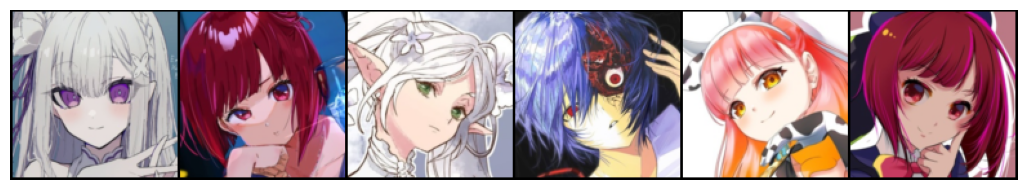

• portrait, purple eyes, long hair, pointy ears, white hair, blush, hair ornament, 1girl
• 1girl, looking at viewer, red eyes, blush, red hair, bob cut
• elf, white hair, long hair, pointy ears, green eyes, portrait, 1girl, flower
• short hair, portrait, 1girl, red eyes, blue hair
• (dropped -> unconditional)
• red eyes, bob cut, red hair, 1girl, school uniform, bow


In [5]:
#@title peek
imgs, caps = next(iter(train_loader))
grid = vutils.make_grid((imgs[:6] + 1) / 2, nrow=6, padding=2)
plt.figure(figsize=(13, 2.4)); plt.axis("off")
plt.imshow(grid.permute(1, 2, 0).numpy()); plt.show()
for c in caps[:6]:
    print("•", c if c else "(dropped -> unconditional)")

## The frozen parts: VAE + CLIP

Exactly as in real Stable Diffusion — these are **pretrained and frozen**, we only train the UNet.

- **VAE:** `vq-f4` from the original LDM paper (`CompVis/ldm-celebahq-256`). Face-trained, 4× downsample, 3 latent channels.
- **Text encoder:** CLIP ViT-L/14 — **the exact text encoder Stable Diffusion v1.x uses.** Outputs `[B, 77, 768]`.

In [6]:
#@title load + freeze the VAE
vae = VQModel.from_pretrained("CompVis/ldm-celebahq-256", subfolder="vqvae").to(device)
vae.eval().requires_grad_(False)

LATENT_CHANNELS = vae.config.latent_channels                       # 3
DOWN_FACTOR     = 2 ** (len(vae.config.block_out_channels) - 1)    # 4
LATENT_SIZE     = IMAGE_SIZE // DOWN_FACTOR                        # 32
print(f"VAE ✓  latent = {LATENT_CHANNELS}×{LATENT_SIZE}×{LATENT_SIZE}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

An error occurred while trying to fetch CompVis/ldm-celebahq-256: CompVis/ldm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


vqvae/diffusion_pytorch_model.bin:   0%|          | 0.00/221M [00:00<?, ?B/s]

VAE ✓  latent = 3×32×32


In [7]:
#@title load + freeze CLIP  (SD v1.x's text encoder)
tokenizer    = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14").to(device)
text_encoder.eval().requires_grad_(False)

CROSS_DIM = text_encoder.config.hidden_size    # 768
MAX_LEN   = tokenizer.model_max_length         # 77

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.

CLIP ✓  embeddings: (1, 77, 768)


In [5]:
@torch.no_grad()
def encode_text(captions):
    tok = tokenizer(captions, padding="max_length", max_length=MAX_LEN,
                    truncation=True, return_tensors="pt").to(device)
    return text_encoder(tok.input_ids)[0]      # [B, 77, 768]

print("CLIP ✓  embeddings:", tuple(encode_text(["1girl, pink hair"]).shape))

CLIP ✓  embeddings: (1, 77, 768)


In [8]:
#@title latent scale + encode/decode helpers
batch0, _ = next(iter(train_loader))
with torch.no_grad():
    h0 = vae.encode(batch0.to(device)).latents
LATENT_SCALE = h0.std().item()
print(f"LATENT_SCALE = {LATENT_SCALE:.4f}")

LATENT_SCALE = 1.0840


In [7]:
@torch.no_grad()
def encode(images):
    # [-1,1] pixels -> unit-scaled continuous latents
    return vae.encode(images.to(device)).latents / LATENT_SCALE

@torch.no_grad()
def decode(latents):
    # latents -> [-1,1] pixels (the frozen quantizer is applied inside decode)
    return vae.decode(latents * LATENT_SCALE).sample

## The UNet — `UNet2DConditionModel`

Note the class change: the unconditional lab used `UNet2DModel`. Text conditioning needs
**`UNet2DConditionModel`**, whose `CrossAttn*` blocks accept `encoder_hidden_states` — the CLIP
embeddings. That's the architectural difference between "a diffusion model" and "Stable Diffusion".

`cross_attention_dim=768` must match CLIP's hidden size.

In [9]:
#@title the text-conditioned UNet
model = UNet2DConditionModel(
    sample_size=LATENT_SIZE,                 # 32
    in_channels=LATENT_CHANNELS,             # 3
    out_channels=LATENT_CHANNELS,            # 3
    layers_per_block=2,
    block_out_channels=(128, 256, 384),      # 32 -> 16 -> 8
    down_block_types=("DownBlock2D",             # 32: conv only (cheap)
                      "CrossAttnDownBlock2D",    # 16: text attends here
                      "CrossAttnDownBlock2D"),   #  8: text attends here
    up_block_types  =("CrossAttnUpBlock2D",
                      "CrossAttnUpBlock2D",
                      "UpBlock2D"),
    cross_attention_dim=CROSS_DIM,           # 768 = CLIP hidden size
    attention_head_dim=8,
    norm_num_groups=32,
).to(device)

print(f"UNet params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

UNet params: 67.8M


In [10]:
#@title schedulers
noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2")
sampling_scheduler = DDIMScheduler.from_config(noise_scheduler.config)
sampling_scheduler.set_timesteps(50)
print("train T:", noise_scheduler.config.num_train_timesteps, "| DDIM steps:", len(sampling_scheduler.timesteps))

train T: 1000 | DDIM steps: 50


### The loss — LDM Eq. 2, in code

Below is a direct transcription of
$\mathcal{L}_{LDM}=\mathbb{E}\big[\lVert \epsilon-\epsilon_\theta(z_t,t,\tau_\theta(c))\rVert_2^2\big]$,
with **Min-SNR-γ** weighting on top (Hang et al. 2023) — it treats the timesteps as a multi-task
problem and rebalances them so the easy low-noise steps don't dominate the gradient. It converges
faster; the objective is otherwise unchanged.

In [11]:
#@title diffusion loss (Min-SNR-γ weighted)
SNR_GAMMA = 5.0

def diffusion_loss(images, captions):
    z    = encode(images)                       # 1. frozen VAE
    ctx  = encode_text(captions)                # 2. frozen CLIP
    eps  = torch.randn_like(z)                  # 3. noise
    t    = torch.randint(0, noise_scheduler.config.num_train_timesteps,
                         (z.shape[0],), device=device).long()
    z_t  = noise_scheduler.add_noise(z, eps, t) # 4. closed-form corruption
    pred = model(z_t, t, encoder_hidden_states=ctx).sample   # 5. predict the noise

    # 6. per-sample MSE  ->  || eps - eps_theta ||^2
    mse = F.mse_loss(pred, eps, reduction="none").mean(dim=[1, 2, 3])

    # Min-SNR-gamma reweighting (eps-prediction form)
    acp = noise_scheduler.alphas_cumprod.to(device)[t]
    snr = acp / (1 - acp)
    w   = torch.clamp(snr, max=SNR_GAMMA) / snr
    return (w * mse).mean()

## The sampler (with a `guidance_scale` knob)

We write **one** sampler with a `guidance_scale` argument now, so the rest of the lab can compare
values side by side. `guidance_scale=1.0` disables guidance — that's plain conditional sampling.
The machinery is explained in sections 5–6; for now just note it runs the UNet on
`[uncond; cond]` in **one batched pass**.

In [3]:
#@title CFG sampler
@torch.no_grad()
def sample(prompts, guidance_scale=7.5, steps=50, seed=None):
    was_training = model.training
    model.eval()
    if isinstance(prompts, str): prompts = [prompts]
    B = len(prompts)

    sched = DDIMScheduler.from_config(noise_scheduler.config)
    sched.set_timesteps(steps)

    cond   = encode_text(prompts)
    do_cfg = guidance_scale != 1.0
    if do_cfg:
        uncond = encode_text([""] * B)          # the empty prompt
        ctx    = torch.cat([uncond, cond])      # [2B, 77, 768]
    else:
        ctx = cond

    g = torch.Generator(device=device).manual_seed(seed) if seed is not None else None
    z = torch.randn(B, LATENT_CHANNELS, LATENT_SIZE, LATENT_SIZE, device=device, generator=g)
    z = z * sched.init_noise_sigma

    for t in sched.timesteps:
        inp  = torch.cat([z] * 2) if do_cfg else z
        inp  = sched.scale_model_input(inp, t)
        pred = model(inp, t, encoder_hidden_states=ctx).sample
        if do_cfg:
            pred_uncond, pred_cond = pred.chunk(2)
            pred = pred_uncond + guidance_scale * (pred_cond - pred_uncond)   # <- the CFG line
        z = sched.step(pred, t, z).prev_sample

    imgs = (decode(z).clamp(-1, 1) + 1) / 2
    if was_training: model.train()
    return imgs.cpu()

def show_grid(imgs, title="", cols=8, labels=None):
    n = imgs.shape[0]; rows = math.ceil(n / cols)
    plt.figure(figsize=(1.9 * cols, 2.05 * rows))
    grid = vutils.make_grid(imgs, nrow=cols, padding=2)
    plt.imshow(grid.permute(1, 2, 0).numpy()); plt.axis("off")
    if title: plt.title(title)
    plt.show()
    if labels:
        for l in labels: print("•", l)

## 4. Training

Mixed precision, step-based, with periodic **preview / eval / flush**. The **val loss** tells you
about overfitting; the **previews** tell you about quality (diffusion loss plateaus early and is a
poor quality signal).

> Set `TOTAL_STEPS` high (15k–40k) for real results. Text conditioning needs noticeably more
> steps than the unconditional model did — the UNet has to learn language grounding too.

In [13]:
#@title training config
TOTAL_STEPS   = 8000      # bump for real quality
LR            = 1e-4
GRAD_CLIP     = 1.0

LOG_EVERY     = 50
VAL_EVERY     = 500
PREVIEW_EVERY = 1000
FLUSH_EVERY   = 1000

PREVIEW_PROMPTS = [
    "1girl, pink hair, green eyes, smile",
    "1girl, blonde hair, blue eyes, long hair",
    "1girl, black hair, red eyes, serious",
    "1girl, white hair, purple eyes, short hair",
]

optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=1e-6)
lr_scheduler = CosineAnnealingLR(optimizer, T_max=TOTAL_STEPS)
scaler       = torch.amp.GradScaler(device)

train_hist, val_hist = [], []
print(f"configured for {TOTAL_STEPS:,} steps")

configured for 8,000 steps


In [14]:
#@title validation
@torch.no_grad()
def validate(max_batches=20):
    model.eval()
    tot = n = 0
    for i, (images, caps) in enumerate(val_loader):
        if i >= max_batches: break
        with torch.autocast(device, enabled=(device == "cuda")):
            tot += diffusion_loss(images, caps).item(); n += 1
    model.train()
    return tot / max(n, 1)

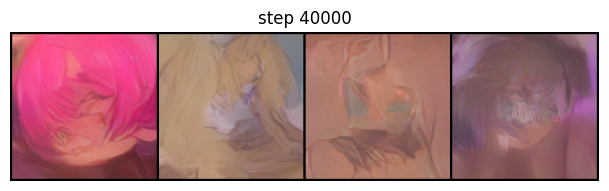

training complete ✓


In [41]:
#@title train
from IPython.display import clear_output

def cycle(loader):
    while True:
        for b in loader: yield b
train_iter = cycle(train_loader)

model.train()
running = 0.0
pbar = tqdm(range(1, TOTAL_STEPS + 1), desc="training")

for step in pbar:
    images, caps = next(train_iter)

    optimizer.zero_grad(set_to_none=True)
    with torch.autocast(device, enabled=(device == "cuda")):
        loss = diffusion_loss(images, caps)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    scaler.step(optimizer); scaler.update()
    lr_scheduler.step()

    running += loss.item()

    if step % LOG_EVERY == 0:
        avg = running / LOG_EVERY; running = 0.0
        train_hist.append((step, avg))
        pbar.set_postfix(loss=f"{avg:.4f}", lr=f"{lr_scheduler.get_last_lr()[0]:.1e}")

    if step % VAL_EVERY == 0:
        val_hist.append((step, validate()))

    if step % FLUSH_EVERY == 0:
        clear_output(wait=True)

    if step % PREVIEW_EVERY == 0:
        show_grid(sample(PREVIEW_PROMPTS, guidance_scale=7.5, steps=50),
                  title=f"step {step}", cols=4)

print("training complete ✓")

In [38]:
TOTAL_STEPS   = 40000
lr_scheduler = CosineAnnealingLR(optimizer, T_max=TOTAL_STEPS)

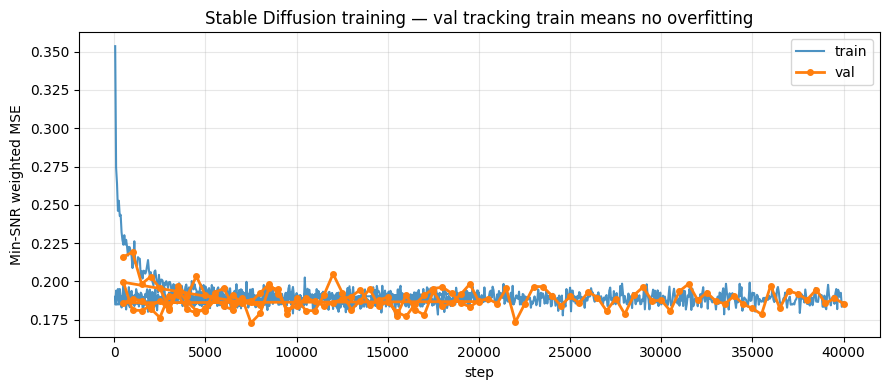

In [47]:
#@title training history (train vs val -> overfitting check)
plt.figure(figsize=(9, 4))
if train_hist:
    ts, ls = zip(*train_hist); plt.plot(ts, ls, label="train", lw=1.5, alpha=0.8)
if val_hist:
    vs, vl = zip(*val_hist);   plt.plot(vs, vl, label="val", lw=2, marker="o", ms=4)
plt.xlabel("step"); plt.ylabel("Min-SNR weighted MSE")
plt.title("Stable Diffusion training — val tracking train means no overfitting")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. The problem: conditional diffusion follows prompts *weakly*

Our model is trained and conditional. So sample with `guidance_scale=1.0` — **pure**
$\epsilon_\theta(z_t,t,c)$, no guidance — and look carefully.

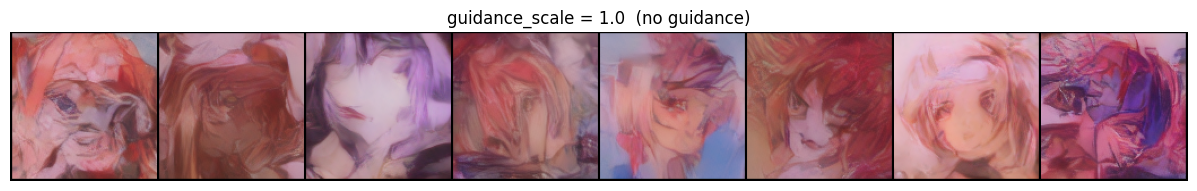

In [16]:
steps = 80
#@title plain conditional sampling — no guidance
prompts = ["1girl, pink hair, green eyes, smile"] * 8
show_grid(sample(prompts, guidance_scale=1.0, steps=steps, seed=1234),
          title="guidance_scale = 1.0  (no guidance)", cols=8)

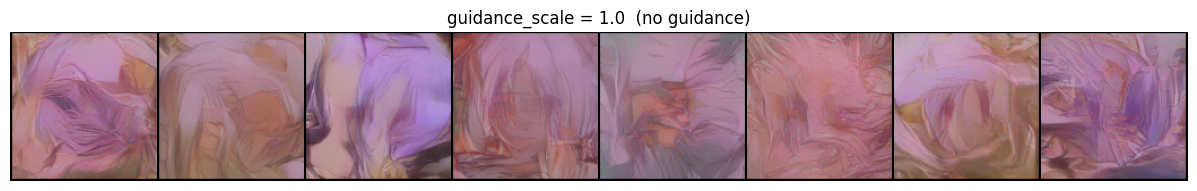

In [23]:
#@title plain conditional sampling — guidance
prompts = ["1girl, black hair, green eyes, smile"] * 8
show_grid(sample(prompts, guidance_scale=7.0, steps=steps, seed=1234),
          title="guidance_scale = 1.0  (no guidance)", cols=8)

In [1]:
#@title login
from getpass import getpass

# Prompts you to paste the token — it won't be echoed or saved in notebook output
HF_TOKEN = getpass("Enter your Hugging Face token: ")
from huggingface_hub import login

login(token=HF_TOKEN)
import os
print(f'logged in')

Enter your Hugging Face token: ··········
logged in


In [42]:
#@title push trained UNet to Hugging Face
from huggingface_hub import HfApi, create_repo, whoami, login
import torch, json

# login()   # <- uncomment on first run, paste a WRITE token

REPO_NAME = "SD-anime-68k-ckpt"
repo_id   = f"{whoami()['name']}/{REPO_NAME}"
OUT       = "sd_anime_upload"
print("repo:", repo_id)

# 1. UNet weights + config.json  (config.json = the arch, so from_pretrained rebuilds it)
model.save_pretrained(OUT)

# 2. scheduler config
noise_scheduler.save_config(f"{OUT}/scheduler")

# 3. training state (resume / plots)
torch.save({
    "optimizer":    optimizer.state_dict(),
    "lr_scheduler": lr_scheduler.state_dict(),
    "scaler":       scaler.state_dict(),
    "train_hist":   train_hist,
    "val_hist":     val_hist,
}, f"{OUT}/training_state.pt")

# 4. the constants sampling needs (NOT recoverable from weights alone)
meta = {
    "latent_scale":     LATENT_SCALE,        # critical: sampling breaks without it
    "latent_channels":  LATENT_CHANNELS,
    "latent_size":      LATENT_SIZE,
    "image_size":       IMAGE_SIZE,
    "cross_dim":        CROSS_DIM,
    "vae_repo":         "CompVis/ldm-celebahq-256",
    "vae_subfolder":    "vqvae",
    "text_encoder_repo":"openai/clip-vit-large-patch14",
    "snr_gamma":        SNR_GAMMA,
    "dropout_prob":     DROPOUT_PROB,        # 0.10 -> CFG-capable
    "max_tags":         MAX_TAGS,
    "total_steps":      TOTAL_STEPS,
    "dataset":          "puruchinera/anime-faces-256",
}
with open(f"{OUT}/meta.json", "w") as f:
    json.dump(meta, f, indent=2)

# 5. push
create_repo(repo_id, exist_ok=True)
HfApi().upload_folder(folder_path=OUT, repo_id=repo_id,
                      commit_message="Text-conditioned UNet (vq-f4 latents, CLIP ViT-L/14)")
print("done →", f"https://huggingface.co/{repo_id}")

repo: AnasKAN/SD-anime-68k-ckpt
done → https://huggingface.co/AnasKAN/SD-anime-68k-ckpt


In [2]:
#@title load SD-anime-no-guidance from Hugging Face
import torch, json
from huggingface_hub import hf_hub_download, whoami
from diffusers import UNet2DConditionModel, VQModel, DDPMScheduler, DDIMScheduler
from transformers import CLIPTextModel, CLIPTokenizer

REPO_NAME = "SD-anime-68k-ckpt"
repo_id   = f"{whoami()['name']}/{REPO_NAME}"      # or hard-code "user/SD-anime-no-guidance"
device    = "cuda" if torch.cuda.is_available() else "cpu"


def load_meta(repo_id):
    with open(hf_hub_download(repo_id, "meta.json")) as f:
        return json.load(f)

def load_model(repo_id, device):
    # arch comes from config.json — no need to redefine UNet2DConditionModel(...)
    return UNet2DConditionModel.from_pretrained(repo_id).to(device).eval()

def load_vae(meta, device):
    v = VQModel.from_pretrained(meta["vae_repo"], subfolder=meta["vae_subfolder"])
    return v.to(device).eval().requires_grad_(False)

def load_text_encoder(meta, device):
    tok = CLIPTokenizer.from_pretrained(meta["text_encoder_repo"])
    te  = CLIPTextModel.from_pretrained(meta["text_encoder_repo"]).to(device)
    te.eval().requires_grad_(False)
    return tok, te

def load_schedulers(repo_id, sample_steps=50):
    noise_sched = DDPMScheduler.from_pretrained(repo_id, subfolder="scheduler")
    ddim = DDIMScheduler.from_config(noise_sched.config)
    ddim.set_timesteps(sample_steps)
    return noise_sched, ddim

def load_training_state(repo_id):
    return torch.load(hf_hub_download(repo_id, "training_state.pt"), map_location="cpu")


meta                    = load_meta(repo_id)
model                   = load_model(repo_id, device)
vae                     = load_vae(meta, device)
tokenizer, text_encoder = load_text_encoder(meta, device)
noise_scheduler, sampling_scheduler = load_schedulers(repo_id, sample_steps=50)
state                   = load_training_state(repo_id)

# restore constants
LATENT_SCALE    = meta["latent_scale"]
LATENT_CHANNELS = meta["latent_channels"]
LATENT_SIZE     = meta["latent_size"]
IMAGE_SIZE      = meta["image_size"]
CROSS_DIM       = meta["cross_dim"]
MAX_LEN         = tokenizer.model_max_length
train_hist, val_hist = state["train_hist"], state["val_hist"]

print(f"loaded {repo_id}")
print(f"UNet {sum(p.numel() for p in model.parameters())/1e6:.1f}M | "
      f"latent {LATENT_CHANNELS}×{LATENT_SIZE}×{LATENT_SIZE} | scale {LATENT_SCALE:.4f}")
print(f"history: {len(train_hist)} train / {len(val_hist)} val points")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


meta.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/1.71k [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/271M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.

scheduler_config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

training_state.pt:   0%|          | 0.00/543M [00:00<?, ?B/s]

loaded AnasKAN/SD-anime-68k-ckpt
UNet 67.8M | latent 3×32×32 | scale 1.0840
history: 1360 train / 136 val points


The samples are **diverse and plausible**, but the prompt is more of a *suggestion* than an
instruction — you'll see hair that drifts off-pink, missing smiles, ignored eye colour.

**Why?** The model was trained to maximise likelihood $p(z|c)$. It faithfully reproduces the data
distribution — and in the data, `pink hair` is only *one* of many correlated attributes. Nothing in
the MSE objective says "make the prompt **dominant**." A sample that ignores a tag is still a
perfectly good sample of the *overall* distribution.

We want a knob to trade **diversity** for **prompt fidelity**. Two ideas follow.

## 6. Fix #1 — Classifier guidance

**Dhariwal & Nichol, 2021** ("Diffusion Models Beat GANs"). The idea: use Bayes' rule to sharpen
the conditional distribution.

We want to sample from $p(z|c)$, biased toward *high* $p(c|z)$. Take logs and gradients:

$$\nabla_z \log p(z|c) = \nabla_z \log p(z) + \nabla_z \log p(c|z)$$

The first term is what an **unconditional** diffusion model already gives us. The second is the
gradient of a **classifier** — how strongly does this latent look like class $c$? Scale it by $s$
to over-emphasise the condition:

$$\hat{\epsilon}(z_t,t,c) = \epsilon_\theta(z_t,t) - s\,\sqrt{1-\bar\alpha_t}\;\nabla_{z_t}\log p_\phi(c\,|\,z_t)$$

Sketch (**illustrative — we do not run this**):

```python
# needs a separate classifier trained on NOISY latents at every timestep
with torch.enable_grad():
    z_in = z_t.detach().requires_grad_(True)
    logits = classifier(z_in, t)               # p(c | z_t)
    logp   = logits.log_softmax(-1)[:, target_class].sum()
    grad   = torch.autograd.grad(logp, z_in)[0]

eps_hat = model(z_t, t).sample - s * (1 - acp[t]).sqrt() * grad
```

**Why nobody does this anymore:**

- You must **train a whole extra classifier** — and it has to work on *noisy* inputs at every
  timestep, so an off-the-shelf classifier won't do.
- It only handles a **fixed label set**. Our tags are free-form text — you'd need a classifier per
  concept. Not workable for open-vocabulary prompts.
- Sampling needs a **backward pass through the classifier at every step** → slow.
- You're pushing on the classifier's gradients, so you partly generate **adversarial examples** for it
  rather than better images.

The obvious question: *can we get the same effect without any classifier?*

## 7. Fix #2 — Classifier-**free** guidance ✅

**Ho & Salimans, 2022.** Apply Bayes' rule to the classifier term instead:

$$\log p(c|z) = \log p(z|c) - \log p(z) + \text{const}
\;\;\Longrightarrow\;\;
\nabla_z \log p(c|z) = \nabla_z \log p(z|c) - \nabla_z \log p(z)$$

The classifier gradient equals **(conditional score − unconditional score)**. And both of those are
just diffusion-model outputs! Substituting back gives the CFG rule:

$$\boxed{\;\hat{\epsilon} = \epsilon_\theta(z_t,t,\varnothing) \;+\; s\,\big[\epsilon_\theta(z_t,t,c) - \epsilon_\theta(z_t,t,\varnothing)\big]\;}$$

Read it as a vector: start at the unconditional prediction, then **walk in the direction the prompt
pulls, but $s$ times too far.** That direction *is* the classifier gradient, obtained for free.

- $s=1$ → plain conditional sampling (the bracket cancels)
- $s=0$ → ignore the prompt entirely
- $s>1$ → **extrapolate** past the conditional prediction: stronger prompt adherence, less diversity

This is why we needed **10% caption dropout** during training: one network learned *both*
$\epsilon_\theta(\cdot,c)$ and $\epsilon_\theta(\cdot,\varnothing)$. No extra model, no classifier,
no per-step backward pass — just **one extra forward pass**, which we batch together:

```python
pred = model(torch.cat([z]*2), t, encoder_hidden_states=torch.cat([uncond, cond])).sample
pred_uncond, pred_cond = pred.chunk(2)
pred = pred_uncond + guidance_scale * (pred_cond - pred_uncond)
```

That's the `sample()` function you already have. **Every modern text-to-image model uses this.**

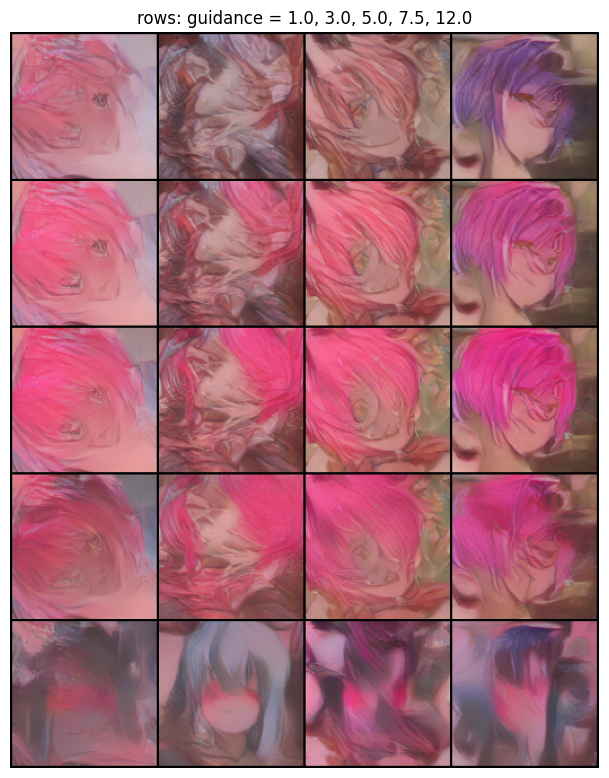

In [18]:
#@title guidance scale sweep — same seed, same prompt
prompt = "1girl, pink hair, green eyes, smile"
scales = [1.0, 3.0, 5.0, 7.5, 12.0]

rows = [sample([prompt] * 4, guidance_scale=s, steps=steps, seed=7) for s in scales]
imgs = torch.cat(rows)
show_grid(imgs, title="rows: guidance = " + ", ".join(str(s) for s in scales), cols=4)

**Read the sweep top to bottom:**

- **s = 1** — diverse, but the prompt is loosely followed
- **s = 3–7.5** — the sweet spot: pink hair and the smile actually appear, samples stay varied
- **s = 12** — over-saturated, high-contrast, samples within a row start to **collapse toward each
  other**. Guidance trades **diversity for fidelity**, and past a point it burns the image.

This is exactly the trade-off the `guidance_scale` slider exposes in every SD UI. (SD's default is
7.5 for a reason.) Note our small model saturates earlier than full SD — small models tend to need
lower scales.

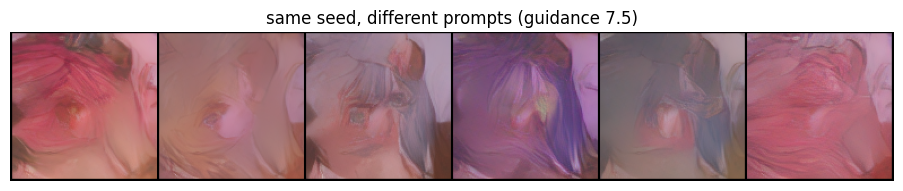

• 1girl, pink hair, green eyes
• 1girl, blonde hair, blue eyes
• 1girl, black hair, red eyes
• 1girl, white hair, purple eyes
• 1girl, blue hair, yellow eyes
• 1girl, red hair, brown eyes


In [19]:
#@title does the prompt actually control the output?
prompts = [
    "1girl, pink hair, green eyes",
    "1girl, blonde hair, blue eyes",
    "1girl, black hair, red eyes",
    "1girl, white hair, purple eyes",
    "1girl, blue hair, yellow eyes",
    "1girl, red hair, brown eyes",
]
# same seed everywhere -> differences are caused by the TEXT alone
imgs = torch.cat([sample([p], guidance_scale=7.5, steps=50, seed=99) for p in prompts])
show_grid(imgs, title="same seed, different prompts (guidance 7.5)", cols=6, labels=prompts)

## 8. Mix & match: building pipelines from pretrained parts

Our from-scratch model teaches the mechanics; production models are the same three parts, trained
far longer on far more data. Because `diffusers` treats them as **swappable modules**, you can
assemble your own combinations.

### The compatibility rules (the only things that matter)

| Swap | Must match |
|---|---|
| **VAE** | `latent_channels` ↔ UNet `in/out_channels`; same downsample factor & latent scaling |
| **Text encoder** | hidden size ↔ UNet `cross_attention_dim` (SD1.x: **768**, SD2.x: **1024**, SDXL: **2048** via *two* encoders) |
| **Scheduler** | freely swappable — schedulers have **no weights** ✅ |
| **UNet** | the heart; swapping it = swapping the model |

> **Rule of thumb:** schedulers are always safe to swap. VAEs swap within a family (any SD1.x VAE
> into any SD1.x pipeline). Text encoders essentially never swap across families — the dimensions
> don't line up.

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

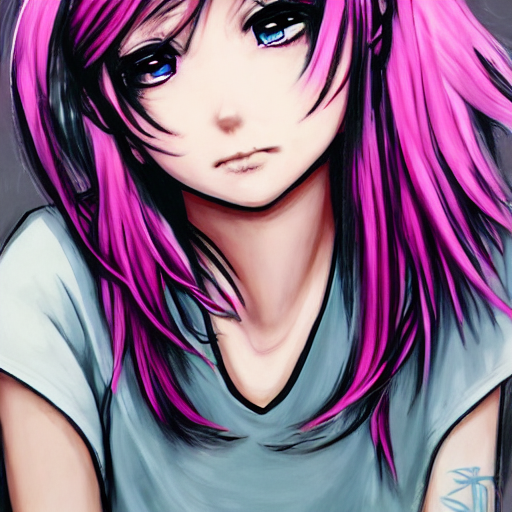

In [24]:
#@title A. the easy way — a full pretrained pipeline
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
).to(device)
pipe.set_progress_bar_config(disable=True)

img = pipe("anime girl with pink hair and green eyes, portrait",
           guidance_scale=7.5, num_inference_steps=30).images[0]
img

In [25]:
#@title B. inspect the parts — same three components as ours
print("VAE          :", type(pipe.vae).__name__,
      "| latent ch:", pipe.vae.config.latent_channels,
      "| scaling:", pipe.vae.config.scaling_factor)
print("Text encoder :", type(pipe.text_encoder).__name__,
      "| hidden:", pipe.text_encoder.config.hidden_size)
print("UNet         :", type(pipe.unet).__name__,
      "| cross_attention_dim:", pipe.unet.config.cross_attention_dim,
      f"| params: {sum(p.numel() for p in pipe.unet.parameters())/1e6:.0f}M")
print("Scheduler    :", type(pipe.scheduler).__name__)

VAE          : AutoencoderKL | latent ch: 4 | scaling: 0.18215
Text encoder : CLIPTextModel | hidden: 768
UNet         : UNet2DConditionModel | cross_attention_dim: 768 | params: 860M
Scheduler    : PNDMScheduler


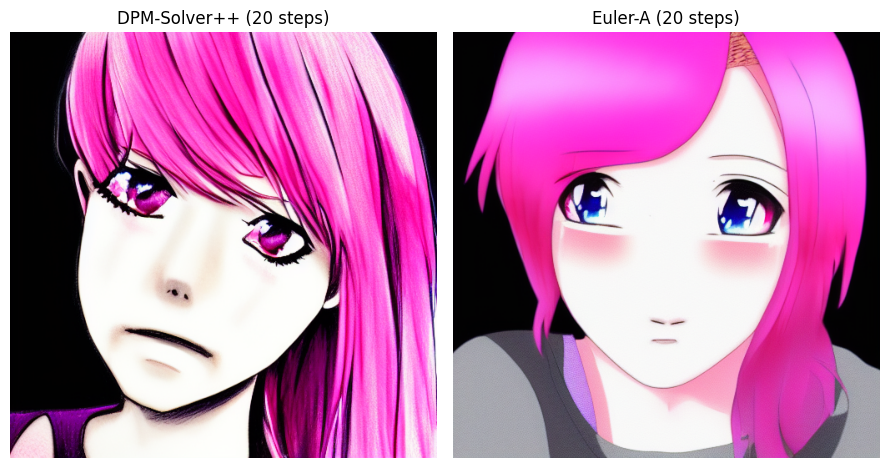

In [26]:
#@title C. swap the SCHEDULER (always safe — no weights)
from diffusers import EulerAncestralDiscreteScheduler, DPMSolverMultistepScheduler

pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
img_dpm = pipe("anime girl with pink hair, portrait",
               guidance_scale=7.5, num_inference_steps=20, generator=torch.Generator(device).manual_seed(0)).images[0]

pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
img_euler = pipe("anime girl with pink hair, portrait",
                 guidance_scale=7.5, num_inference_steps=20, generator=torch.Generator(device).manual_seed(0)).images[0]

fig, ax = plt.subplots(1, 2, figsize=(9, 4.6))
for a, im, t in zip(ax, [img_dpm, img_euler], ["DPM-Solver++ (20 steps)", "Euler-A (20 steps)"]):
    a.imshow(im); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

VAE swapped ✓


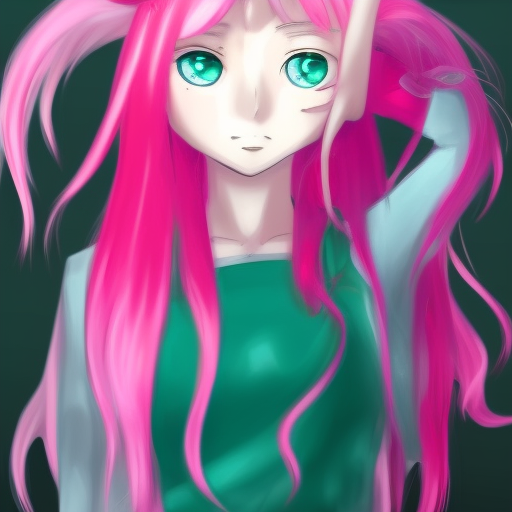

In [27]:
#@title D. swap the VAE (same family -> compatible)
from diffusers import AutoencoderKL

better_vae = AutoencoderKL.from_pretrained(
    "stabilityai/sd-vae-ft-mse",                       # a drop-in improved SD1.x VAE
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
).to(device)

# compatibility check BEFORE swapping
assert better_vae.config.latent_channels == pipe.unet.config.in_channels, "latent channels must match!"
pipe.vae = better_vae
print("VAE swapped ✓")

pipe("anime girl with pink hair and green eyes, portrait",
     guidance_scale=7.5, num_inference_steps=30).images[0]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

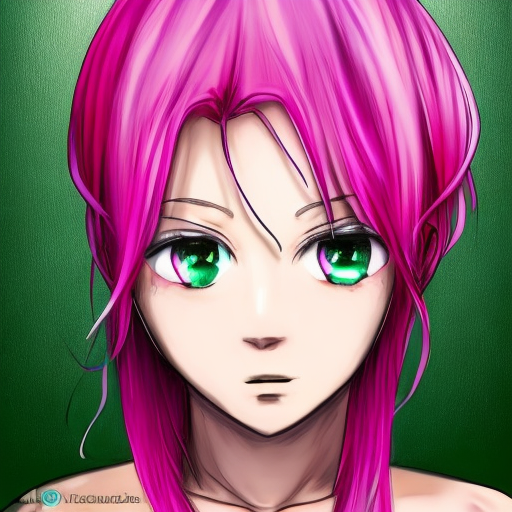

In [29]:
#@title E. assemble a pipeline from parts you chose yourself
from diffusers import StableDiffusionPipeline, UNet2DConditionModel, AutoencoderKL, DDIMScheduler
from transformers import CLIPTextModel, CLIPTokenizer

dt = torch.float16 if device == "cuda" else torch.float32
base = "runwayml/stable-diffusion-v1-5"

custom = StableDiffusionPipeline(
    vae           = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse", torch_dtype=dt),
    text_encoder  = CLIPTextModel.from_pretrained(base, subfolder="text_encoder", torch_dtype=dt),
    tokenizer     = CLIPTokenizer.from_pretrained(base, subfolder="tokenizer"),
    unet          = UNet2DConditionModel.from_pretrained(base, subfolder="unet", torch_dtype=dt),
    scheduler     = DDIMScheduler.from_pretrained(base, subfolder="scheduler"),
    safety_checker=None, feature_extractor=None, requires_safety_checker=False,
).to(device)
custom.set_progress_bar_config(disable=True)

custom("anime girl with pink hair, green eyes, portrait",
       guidance_scale=7.5, num_inference_steps=30).images[0]

In [30]:
#@title F. swap the UNet -> an anime-finetuned model (same SD1.x family)
anime = StableDiffusionPipeline.from_pretrained(
    "Linaqruf/anything-v3.0",                # SD1.x anime finetune: same VAE/CLIP dims
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    safety_checker=None,
).to(device)
anime.set_progress_bar_config(disable=True)

p = "1girl, pink hair, green eyes, smile, portrait, masterpiece"
anime(p, guidance_scale=7.5, num_inference_steps=30,
      generator=torch.Generator(device).manual_seed(0)).images[0]

GatedRepoError: 403 Client Error. (Request ID: Root=1-6a56d076-64e8e7c30ab5a9d350d83439;2c83ed42-f3e4-46c9-b8ad-6c5e4d06e56a)

Cannot access gated repo for url https://huggingface.co/Linaqruf/anything-v3.0/resolve/main/model_index.json.
Access to model Linaqruf/anything-v3.0 is restricted and you are not in the authorized list. Visit https://huggingface.co/Linaqruf/anything-v3.0 to ask for access.

### What *won't* work

```python
# ✗ SD2.x text encoder into an SD1.x UNet
#   OpenCLIP-H hidden = 1024, but the SD1.x UNet expects cross_attention_dim = 768
#   -> shape mismatch in every cross-attention layer

# ✗ SDXL VAE into an SD1.x pipeline at the wrong scaling
#   SDXL uses a different scaling_factor; latents come out mis-scaled -> noise/garbage

# ✗ our vq-f4 VAE (3 latent channels) into a real SD UNet (expects 4)
#   -> in_channels mismatch on the very first conv
```

Always check the three numbers before swapping: **latent channels**, **downsample factor**, and
**cross-attention dim ↔ text hidden size**.

## Recap

| | |
|---|---|
| **Problem** | pixel diffusion wastes compute on imperceptible detail |
| **LDM's fix** | diffuse in a frozen autoencoder's latent space (~48× smaller) |
| **Stable Diffusion** | LDM + CLIP text conditioning via **cross-attention** |
| **Training** | one MSE: $\lVert\epsilon - \epsilon_\theta(z_t,t,\tau_\theta(c))\rVert^2$ |
| **Weak prompts** | likelihood training makes conditioning a suggestion, not a command |
| **Classifier guidance** | works, but needs a noise-aware classifier + a fixed label set |
| **CFG** ✅ | $\hat{\epsilon}=\epsilon_\varnothing + s(\epsilon_c-\epsilon_\varnothing)$ — free via caption dropout |
| **Pipelines** | three swappable modules; match the dims and mix freely |

**Try next:** train longer; use a 4-channel SD VAE so parts swap with real SD; add negative prompts
(pass a real prompt instead of `""` as the unconditional branch — that's all a negative prompt is).